# SIERRALEONE DATASET 

### Importing necessary packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

#### Importing the dataset using pandas read_csv method and saving it as 'data' and describing it using describe

In [2]:
data = pd.read_csv('sierraleone-bumbuna.csv')
data.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,201.957515,116.376337,113.720571,206.643095,198.114691,26.319394,79.448857,1.146113,1.691606,0.363823,133.044668,7.172220,999.876469,0.000967,0.004806,32.504263,32.593091,NaN
std,298.495150,218.652659,158.946032,300.896893,288.889073,4.398605,20.520775,1.239248,1.617053,0.295000,114.284792,7.535093,2.104419,0.031074,0.047556,12.434899,12.009161,NaN
min,-19.500000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,-2.800000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,0.300000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,362.400000,107.000000,224.700000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN


#### Checking whether the dataset has any null values in any column and summing them

In [3]:
data.isna().sum()


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

#### Identifying Columns with >5% Nulls

In [4]:
null_percent = data.isna().mean() * 100
print(null_percent[null_percent > 5])


Comments    100.0
dtype: float64


#### Outlier detection using z-score

In [5]:
numeric_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = np.abs(zscore(data[numeric_cols]))
outliers = (z_scores > 3)
df_outliers = data[(outliers).any(axis=1)]
df_outliers


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
653,2021-10-30 10:54,814.0,257.0,594.3,878.0,856.0,25.9,85.3,0.5,1.1,0.5,81.4,7.9,1002,0,0.0,50.4,45.6,NaN
654,2021-10-30 10:55,826.0,263.5,599.6,883.0,861.0,26.0,85.4,1.7,2.4,0.4,74.6,12.1,1002,0,0.0,51.6,46.6,NaN
655,2021-10-30 10:56,851.0,285.0,605.9,912.0,890.0,26.0,84.2,1.6,2.1,0.5,66.4,14.6,1002,0,0.0,52.4,47.0,NaN
656,2021-10-30 10:57,823.0,254.8,603.9,878.0,856.0,26.0,85.3,0.8,1.6,0.6,90.2,7.0,1002,0,0.0,53.4,47.7,NaN
657,2021-10-30 10:58,810.0,244.5,598.8,864.0,843.0,26.1,85.7,0.6,1.6,0.6,108.5,7.9,1002,0,0.0,54.6,48.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522184,2022-10-27 15:05,167.2,-0.5,165.1,167.6,160.9,30.4,68.3,5.3,6.7,0.9,147.9,10.1,999,0,0.0,36.4,36.4,NaN
522185,2022-10-27 15:06,163.4,-0.6,161.0,165.7,159.2,30.2,67.7,7.1,8.4,0.8,144.5,7.7,999,0,0.0,35.6,35.6,NaN
522194,2022-10-27 15:15,183.5,0.3,181.6,173.7,168.7,29.3,70.2,4.9,5.9,0.7,128.7,14.9,999,0,0.0,35.3,35.1,NaN
523792,2022-10-28 17:53,31.3,-0.5,30.2,34.3,32.3,28.4,79.5,5.0,6.4,0.9,354.4,22.9,999,0,0.0,31.3,31.4,NaN


#### Handling missing values

In [6]:
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
data[numeric_cols]

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
0,-0.7,-0.1,-0.8,0.0,0.0,0.0,0.0
1,-0.7,-0.1,-0.8,0.0,0.0,0.0,0.0
2,-0.7,-0.1,-0.8,0.0,0.0,0.0,0.0
3,-0.7,0.0,-0.8,0.0,0.0,0.0,0.0
4,-0.7,-0.1,-0.8,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
525595,-1.6,-0.1,-2.9,0.0,0.0,0.0,0.0
525596,-1.7,-0.1,-3.0,0.0,0.0,0.0,0.0
525597,-1.7,-0.1,-3.1,0.0,0.0,0.0,0.0
525598,-1.7,-0.2,-3.3,0.0,0.0,0.0,0.0


#### Dropped the "Comments" column because it has no values

In [7]:
data = data.drop(columns=['Comments'])
data.isna().sum()

Timestamp        0
GHI              0
DNI              0
DHI              0
ModA             0
ModB             0
Tamb             0
RH               0
WS               0
WSgust           0
WSstdev          0
WD               0
WDstdev          0
BP               0
Cleaning         0
Precipitation    0
TModA            0
TModB            0
dtype: int64

#### Export cleaned data

In [8]:
data.to_csv('sierraleone_clean.csv', index=False)


#### Convert Timestamp Column to Datetime

In [9]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Timestamp']


0        2021-10-30 00:01:00
1        2021-10-30 00:02:00
2        2021-10-30 00:03:00
3        2021-10-30 00:04:00
4        2021-10-30 00:05:00
                 ...        
525595   2022-10-29 23:56:00
525596   2022-10-29 23:57:00
525597   2022-10-29 23:58:00
525598   2022-10-29 23:59:00
525599   2022-10-30 00:00:00
Name: Timestamp, Length: 525600, dtype: datetime64[ns]

#### Plotting time series as a loop

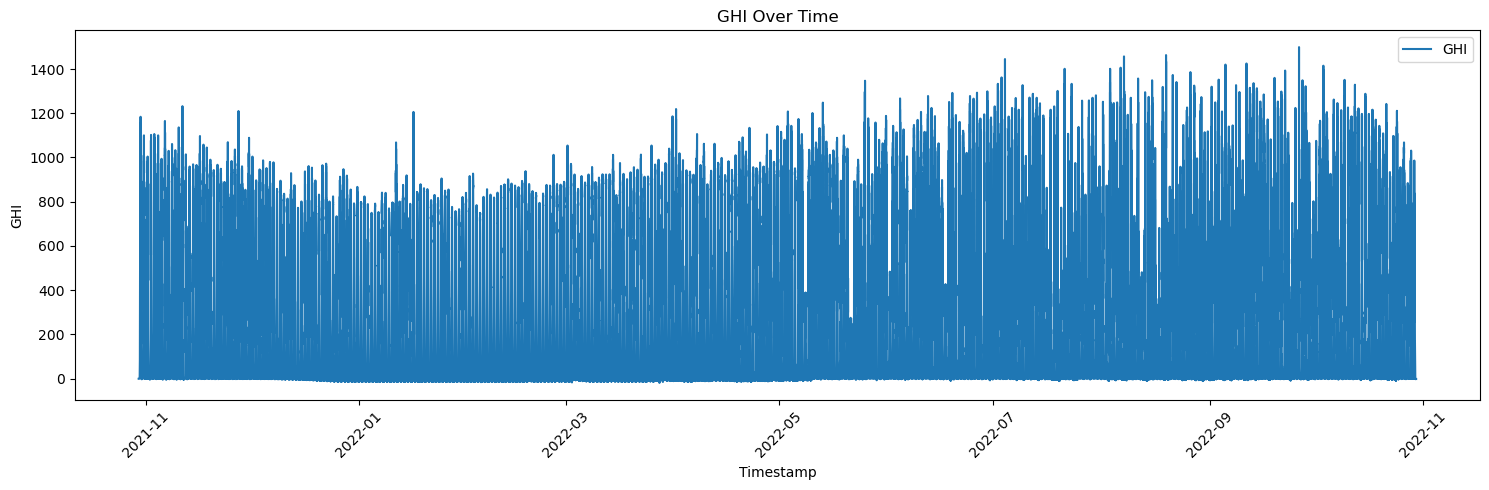

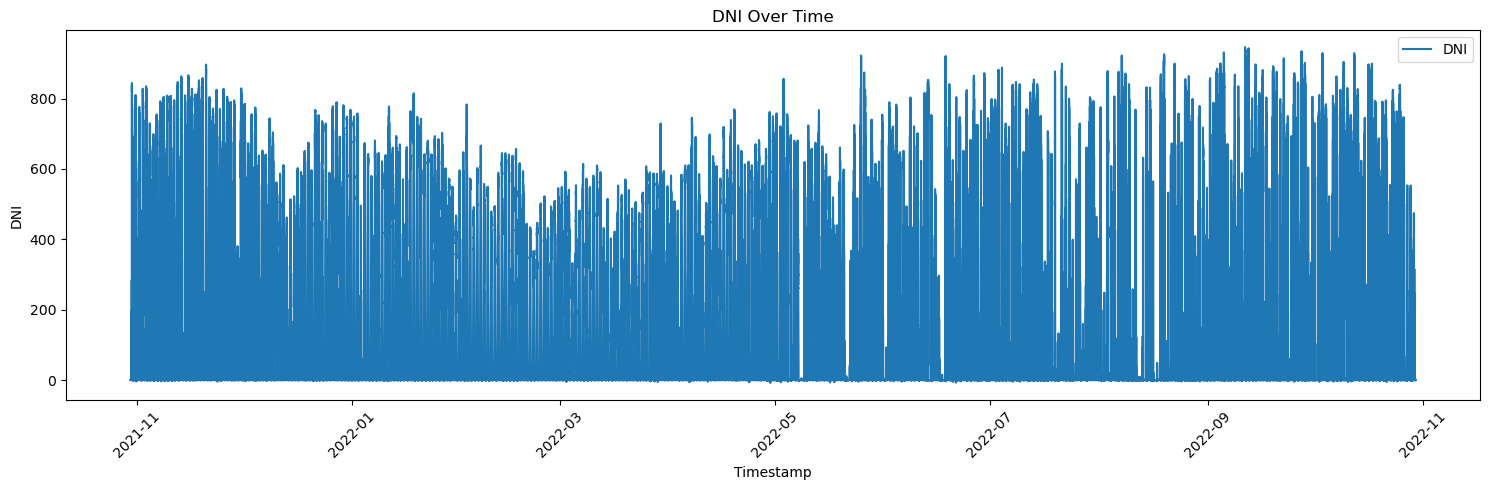

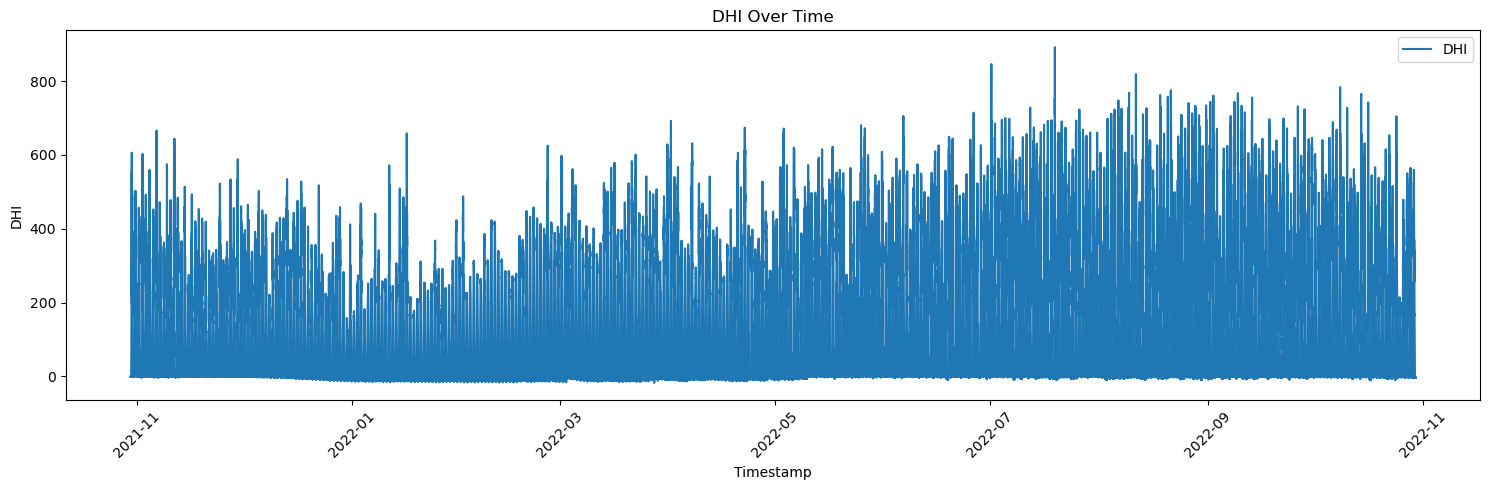

In [10]:
columns = ['GHI', 'DNI', 'DHI']
for col in columns:
    plt.figure(figsize=(15, 5))
    plt.plot(data['Timestamp'], data[col], label=col)
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.title(f'{col} Over Time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Plotting time series individually

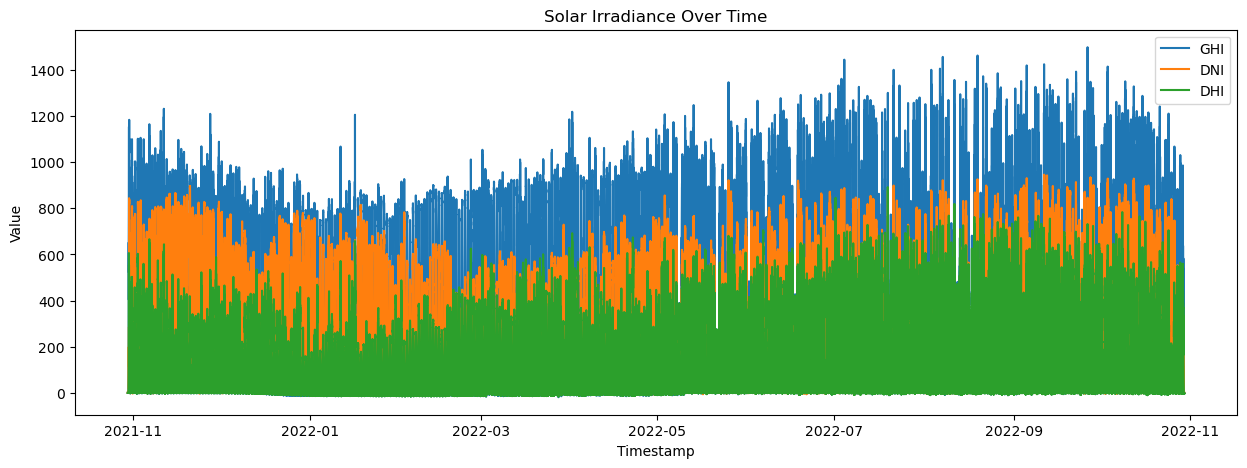

In [11]:
plt.figure(figsize=(15, 5))
plt.plot(data['Timestamp'], data['GHI'], label='GHI')
plt.plot(data['Timestamp'], data['DNI'], label='DNI')
plt.plot(data['Timestamp'], data['DHI'], label='DHI')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Solar Irradiance Over Time')
plt.legend()
plt.show()

#### Barplot

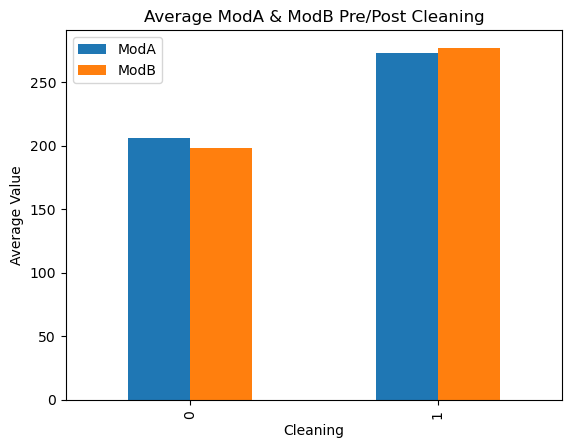

In [12]:
data.groupby('Cleaning')[['ModA', 'ModB']].mean().plot(kind='bar')
plt.title('Average ModA & ModB Pre/Post Cleaning')
plt.ylabel('Average Value')
plt.show()


#### Correlation Heatmap

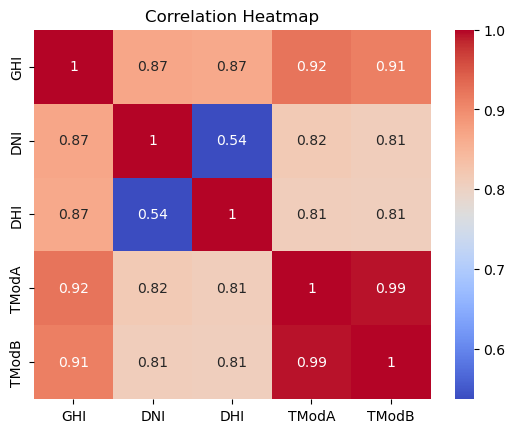

In [13]:
corr = data[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


#### Scatter plots

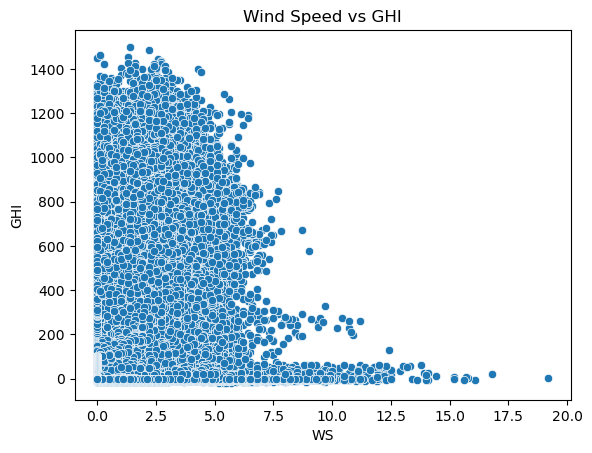

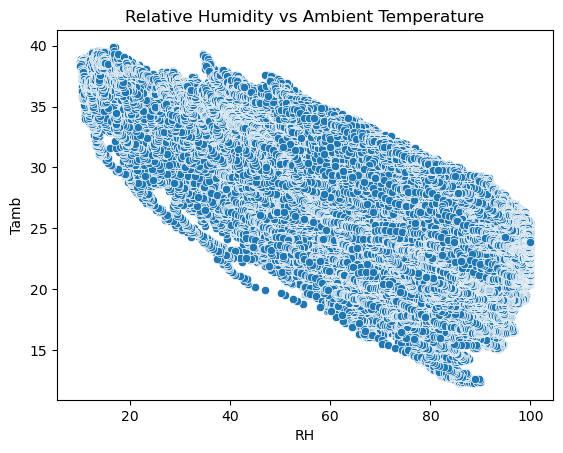

In [14]:
sns.scatterplot(data=data, x='WS', y='GHI')
plt.title('Wind Speed vs GHI')
plt.show()

sns.scatterplot(data=data, x='RH', y='Tamb')
plt.title('Relative Humidity vs Ambient Temperature')
plt.show()


#### Histogram for GHI

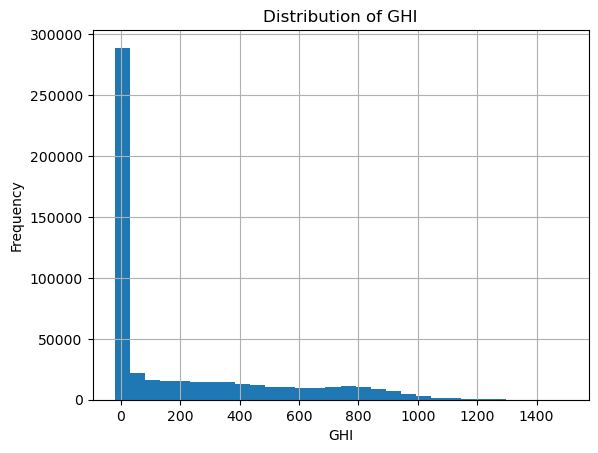

In [15]:
data['GHI'].hist(bins=30)
plt.title('Distribution of GHI')
plt.xlabel('GHI')
plt.ylabel('Frequency')
plt.show()


#### Histogram for WS

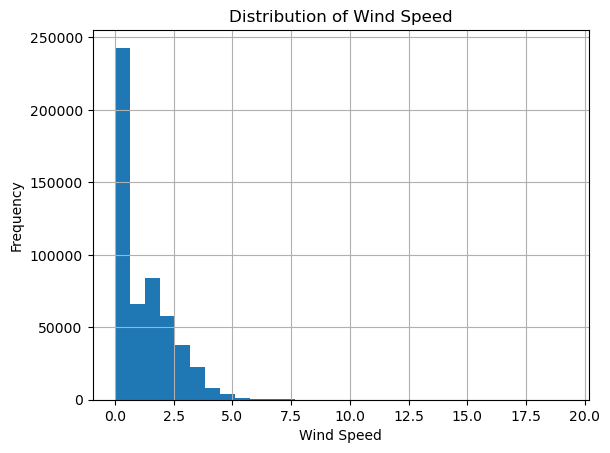

In [16]:
data['WS'].hist(bins=30)
plt.title('Distribution of Wind Speed')
plt.xlabel('Wind Speed')
plt.ylabel('Frequency')
plt.show()


#### Bubble Chart: GHI vs Tamb with RH as Size for temprature analysis

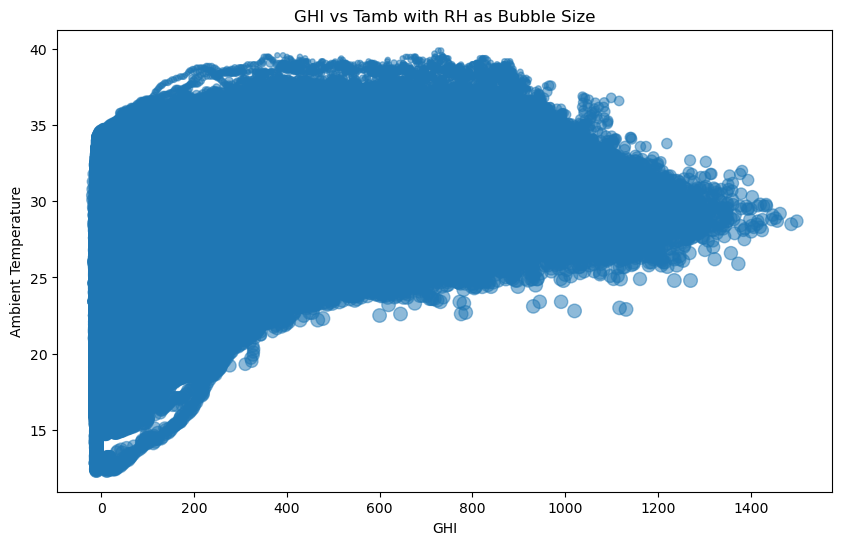

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(data['GHI'], data['Tamb'], s=data['RH'], alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Ambient Temperature')
plt.title('GHI vs Tamb with RH as Bubble Size')
plt.show()
